In [ ]:
import random
import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import time


base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]

duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]

cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]

taxis_battery = [100 for i in range(20)]

battery_threshold = 10


flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)


alpha = 1
beta = 1
gamma = 1


def fitness_function(taxi_assignments):
    fitness = 0
    miu = 0.1
    
    for i in range(len(taxi_assignments)):
        assigned_base_request = taxi_assignments[i]
        if assigned_base_request is not None:
            order_rate_at_request_base = base_order_rate[assigned_base_request]
            cummulative_order_route = cum_order[i][assigned_base_request]
            estimated_duration= duration[i][assigned_base_request]

            d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
            cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
            base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

            
            fitness_component = fir
            fitness += fitness_component
    
    return fitness

def is_valid_solution(solution):
    
    assigned_requests = [req for req in solution if req is not None]
    if len(assigned_requests) != 10:
        return False
    
    
    request_counts = [0] * 10
    for req in assigned_requests:
        if req < 0 or req >= 10:  
            return False
        request_counts[req] += 1
    
    
    if any(count != 1 for count in request_counts):
        return False
    
    
    for i in range(len(solution)):
        assignment = solution[i]
        if assignment is not None:
            taxi_battery = taxis_battery[i]
            battery_consumption = 0.00024524 * distance[i][assignment] + 0 * duration[i][assignment]
            remaining_battery = taxi_battery - battery_consumption
            
            if remaining_battery < battery_threshold:
                return False
    
    return True

def calculate_penalty(solution):
    penalty = 0
    
    
    assigned_requests = [req for req in solution if req is not None]
    
    
    request_counts = {}
    for req in assigned_requests:
        if req is not None:
            if req in request_counts:
                request_counts[req] += 1
            else:
                request_counts[req] = 1
    
    
    for req in range(10):
        if req not in request_counts:
            penalty += 1000  
        elif request_counts[req] > 1:
            penalty += 1000 * (request_counts[req] - 1)  
    
    
    if len(assigned_requests) != 10:
        penalty += 1000 * abs(len(assigned_requests) - 10)
    
    
    for i in range(len(solution)):
        assignment = solution[i]
        if assignment is not None:
            taxi_battery = taxis_battery[i]
            battery_consumption = 0.00024524 * distance[i][assignment] + 0 * duration[i][assignment]
            remaining_battery = taxi_battery - battery_consumption
            
            if remaining_battery < battery_threshold:
                penalty += (battery_threshold - remaining_battery) * 100
    
    return penalty

def penalized_fitness(solution, penalty_weight=1.0):
    return fitness_function(solution) - penalty_weight * calculate_penalty(solution)

class ModifiedDifferentialEvolution:
    def __init__(self, dimension=20, population_size=10, F=0.8, CR=0.8, max_iterations=100, penalty_weight=1.0):
        self.dimension = dimension
        self.population_size = population_size
        self.F = F
        self.CR = CR
        self.max_iterations = max_iterations
        self.penalty_weight = penalty_weight
        
        
        self.target_vectors = []
        self.best_vectors = []
        self.second_best_vectors = []
        self.random_vectors = []
        self.random_selected_vectors = []
        
        
        self.TV_score = 100
        self.BV_score = 100
        self.RV_score = 100
        
        
        self.no_improvement_count = 0
        
        
        self.best_solution = None
        self.best_fitness = float('-inf')
    
    def initialize_population(self):
        self.target_vectors = []
        
        for _ in range(self.population_size):
            
            solution = self._generate_random_solution()
            self.target_vectors.append(solution)
        
        
        self.best_vectors = copy.deepcopy(self.target_vectors)
        
        
        self.second_best_vectors = self._generate_random_vectors(self.population_size)
        
        
        self.random_vectors = self._generate_random_vectors(self.population_size)
        
        
        self.random_selected_vectors = self._generate_random_vectors(self.population_size)
        
        
        self._update_best_solution()
    
    def _generate_random_solution(self):
        
        solution = [None] * self.dimension
        
        
        taxis_to_assign = random.sample(range(self.dimension), 10)
        
        
        available_requests = list(range(10))
        random.shuffle(available_requests)
        
        for i, taxi_idx in enumerate(taxis_to_assign):
            solution[taxi_idx] = available_requests[i]
        
        return solution
    
    def _generate_random_vectors(self, count):
        vectors = []
        for _ in range(count):
            vectors.append(self._generate_random_solution())
        return vectors
    
    def _update_best_solution(self):
        for vector in self.target_vectors:
            fitness = fitness_function(vector)
            if fitness > self.best_fitness and is_valid_solution(vector):
                self.best_solution = copy.deepcopy(vector)
                self.best_fitness = fitness
                self.no_improvement_count = 0
            else:
                self.no_improvement_count += 1
    
    def _select_vector_set(self):
        total_score = self.TV_score + self.BV_score + self.RV_score
        probabilities = [
            self.TV_score / total_score,
            self.BV_score / total_score,
            self.RV_score / total_score
        ]
        
        
        selected_set = random.choices(['TV', 'BV', 'RV'], weights=probabilities, k=1)[0]
        
        if selected_set == 'TV':
            return self.target_vectors
        elif selected_set == 'BV':
            return self.best_vectors
        else:
            return self.random_vectors
    
    def _update_scores(self, used_set, result):
        if result == 'optimal':
            score = 5
        elif result == 'better':
            score = 3
        else:  
            score = 1
        
        if used_set == 'TV':
            self.TV_score += score
        elif used_set == 'BV':
            self.BV_score += score
        else:  
            self.RV_score += score
    
    def _mutation(self, target_idx):
        """
        taget_idx: index individu dallam populasi yg bermutasi
        """
        vector_sets = []
        for _ in range(3):
            vector_set = self._select_vector_set()
            vector_sets.append(vector_set)
        
        
        r1, r2, r3 = random.sample(range(self.population_size), 3)
        mutant_vector = [None] * self.dimension
        
        for i in range(self.dimension):
            
            if (vector_sets[0][r1][i] is not None and 
                vector_sets[1][r2][i] is not None and 
                vector_sets[2][r3][i] is not None):

                rand_val = random.random()
                if rand_val <= self.F:
                    # harusnya: mutant_vector[i] = vector_sets[0][r1][i] + F * (vector_sets[1][r2][i] - vector_sets[2][r3][i]) (tapi tidak bisa untuk GAP)
                    mutant_vector[i] = vector_sets[0][r1][i]
                else:
                    mutant_vector[i] = self.target_vectors[target_idx][i]
            else:
                mutant_vector[i] = self.target_vectors[target_idx][i]
        
        return mutant_vector
    
    def _crossover(self, target_vector, mutant_vector):
        trial_vector = [None] * self.dimension
        
        
        j_rand = random.randint(0, self.dimension - 1)
        
        for j in range(self.dimension):
            
            rand_val = random.random()
            
            
            if rand_val <= self.CR or j == j_rand:
                trial_vector[j] = mutant_vector[j]
            else:
                trial_vector[j] = target_vector[j]
        
        return trial_vector
    
    def _selection(self, target_vector, trial_vector, target_idx):
        
        target_fitness = penalized_fitness(target_vector, self.penalty_weight)
        trial_fitness = penalized_fitness(trial_vector, self.penalty_weight)
        
        
        if trial_fitness >= target_fitness:
            
            self.second_best_vectors[target_idx] = target_vector
            
            
            if random.random() < 0.5:
                self.random_selected_vectors[target_idx] = target_vector
            
            
            if trial_fitness > self.best_fitness and is_valid_solution(trial_vector):
                self.best_solution = copy.deepcopy(trial_vector)
                self.best_fitness = fitness_function(trial_vector)
                self.no_improvement_count = 0
                self._update_scores('TV', 'optimal')
            else:
                self.no_improvement_count += 1
                self._update_scores('TV', 'better')
            
            return trial_vector
        else:
            self._update_scores('TV', 'worse')
            return target_vector
    
    def _local_search(self, vector):
        best_vector = copy.deepcopy(vector)
        best_fitness = penalized_fitness(vector, self.penalty_weight)
        
        
        assigned_positions = [i for i, val in enumerate(vector) if val is not None]
        
        
        for i in range(len(assigned_positions)):
            for j in range(i + 1, len(assigned_positions)):
                pos1 = assigned_positions[i]
                pos2 = assigned_positions[j]
                
                
                new_vector = copy.deepcopy(vector)
                new_vector[pos1], new_vector[pos2] = new_vector[pos2], new_vector[pos1]
                
                
                new_fitness = penalized_fitness(new_vector, self.penalty_weight)
                
                
                if new_fitness > best_fitness:
                    best_vector = copy.deepcopy(new_vector)
                    best_fitness = new_fitness
        
        return best_vector
    
    def optimize(self):
        self.initialize_population()
        for iteration in range(self.max_iterations):
            for i in range(self.population_size):
                mutant_vector = self._mutation(i)                
                trial_vector = self._crossover(self.target_vectors[i], mutant_vector) 
                self.target_vectors[i] = self._selection(self.target_vectors[i], trial_vector, i)
            
            
            self.best_vectors = sorted(self.target_vectors, key=lambda x: penalized_fitness(x, self.penalty_weight), reverse=True)[:self.population_size]
            
            
            local_search_prob = min(1.0, self.no_improvement_count / self.max_iterations)
            
            if random.random() < local_search_prob:
                for i in range(self.population_size):
                    self.best_vectors[i] = self._local_search(self.best_vectors[i])
                    self.second_best_vectors[i] = self._local_search(self.second_best_vectors[i])
                    self.random_selected_vectors[i] = self._local_search(self.random_selected_vectors[i])
                
                
                self.target_vectors = copy.deepcopy(self.best_vectors)
                self.second_best_vectors = self._generate_random_vectors(self.population_size)
                self.random_selected_vectors = self._generate_random_vectors(self.population_size)
            
            
            self.random_vectors = self._generate_random_vectors(self.population_size)
        
        return self.best_solution, self.best_fitness

def run_mde_algorithm(dimension=20, population_size=10, F=0.8, CR=0.8, max_iterations=1000, penalty_weight=1.0, runs=1):
    best_solution = None
    best_fitness = float('-inf')
    
    for run in range(runs):
        
        
        mde = ModifiedDifferentialEvolution(
            dimension=dimension,
            population_size=population_size,
            F=F,
            CR=CR,
            max_iterations=max_iterations,
            penalty_weight=penalty_weight
        )
        
        solution, fitness = mde.optimize()
        
        
        if fitness > best_fitness and is_valid_solution(solution):
            best_solution = copy.deepcopy(solution)
            best_fitness = fitness
    
    return best_solution, best_fitness

def plot_distributions(dimension=20, population_size=10, F=0.8, CR=0.8, max_iterations=1000, penalty_weight=1.0, runs=1000):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    
    for i in range(runs):
        start_time = time.time()
        try:
            mde = ModifiedDifferentialEvolution(
                dimension=dimension,
                population_size=population_size,
                F=F,
                CR=CR,
                max_iterations=max(10, max_iterations // 10),  
                penalty_weight=penalty_weight
            )
            
            solution, fitness = mde.optimize()
            
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
            
            if solution is not None and fitness is not None and is_valid_solution(solution):
                fitness_values.append(fitness)
                valid_runs += 1
                
        except Exception as e:
            print(f"Error in run {i}: {str(e)}")
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
    
    
    
    
    if fitness_values:
        
        mean_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(fitness_values, bins=20, edgecolor='black')
        plt.axvline(mean_fitness, linestyle='--', label=f'Mean = {mean_fitness:.2f}')
        plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':', 
                    label=f'Std = {std_fitness:.2f}')
        plt.title('Objective Function Score (Differential Evolution)')
        plt.xlabel('Fitness')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean fitness: {mean_fitness:.4f}")
        print(f"Std deviation of fitness: {std_fitness:.4f}")
    else:
        mean_fitness = None
        std_fitness = None
        print("No valid solutions found")
    
    
    if duration_values:
        
        mean_duration = np.mean(duration_values)
        std_duration = np.std(duration_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(duration_values, bins=20, edgecolor='black')
        plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
        plt.axvline(mean_duration + std_duration, color='gray', linestyle=':', 
                    label=f'Std = {std_duration:.4f}s')
        plt.title('Computation Time (Differential Evolution)')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean computation time: {mean_duration:.4f} seconds")
        print(f"Std deviation of time: {std_duration:.4f} seconds")
    else:
        mean_duration = None
        std_duration = None
        print("No runs completed")
    
    return mean_fitness, std_fitness, mean_duration, std_duration

Run 1/1
Iteration 100/1000, Best Fitness: 23.39201655663022
Iteration 200/1000, Best Fitness: 23.5076843242972
Iteration 300/1000, Best Fitness: 23.5076843242972
Iteration 400/1000, Best Fitness: 23.5076843242972
Iteration 500/1000, Best Fitness: 23.5076843242972
Iteration 600/1000, Best Fitness: 23.5076843242972
Iteration 700/1000, Best Fitness: 23.5076843242972
Iteration 800/1000, Best Fitness: 23.5076843242972
Iteration 900/1000, Best Fitness: 23.5076843242972
Iteration 1000/1000, Best Fitness: 23.5076843242972
Best solution: [None, None, 4, 2, None, None, None, 9, 7, 1, None, 0, None, 5, 8, 6, 3, None, None, None]
Best fitness: 23.5076843242972
Is valid: True


Running 1000 trials of MDE algorithm...
Completed 100 runs...
Completed 200 runs...
Completed 300 runs...
Completed 400 runs...
Completed 500 runs...
Completed 600 runs...
Completed 700 runs...
Completed 800 runs...
Completed 900 runs...
Valid solutions: 1000/1000 (100.00%)


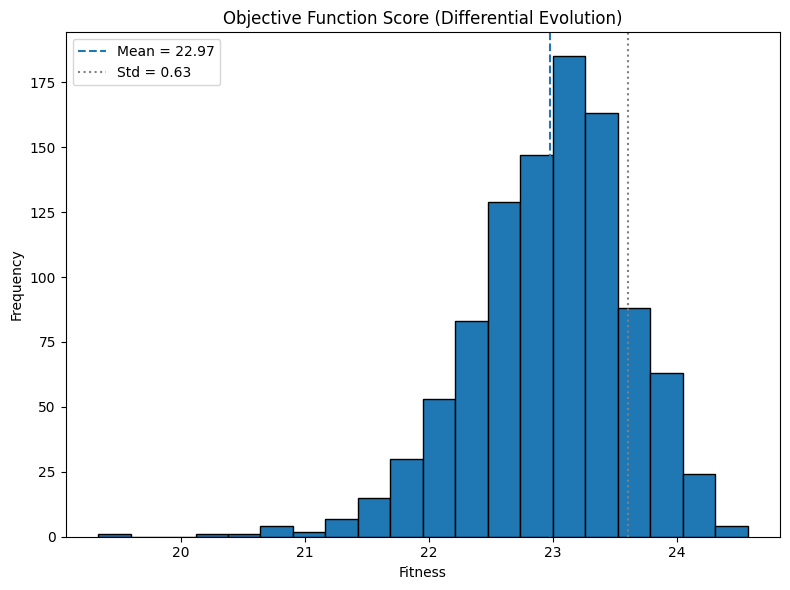

Mean fitness: 22.9728
Std deviation of fitness: 0.6341


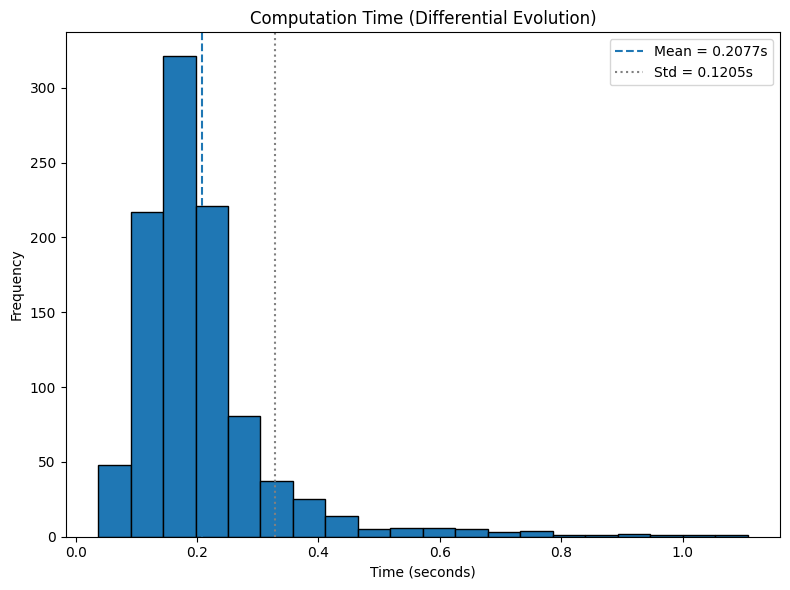

Mean computation time: 0.2077 seconds
Std deviation of time: 0.1205 seconds


In [4]:
mean_fitness, std_fitness, mean_duration, std_duration = plot_distributions(
        population_size=10,
        max_iterations=30,
        penalty_weight=100.0,
        runs=1000 
    )